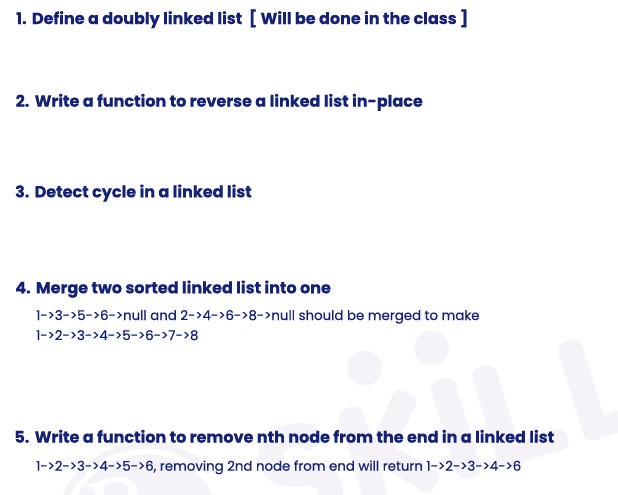

#1
A doubly linked list is a type of linked list where each node contains a data part and two pointers, next and prev. The next pointer points to the next node in the sequence, while the prev pointer points to the previous node. This allows traversal of the list in both forward and backward directions.

In [1]:
class ListNode:
    def __init__(self, val=0, next=None, prev=None):
        self.val = val
        self.next = next
        self.prev = prev


In [2]:
#2
def reverse_linked_list(head):
    prev = None
    current = head
    while current:
        next_node = current.next
        current.next = prev
        prev = current
        current = next_node
    return prev


In [3]:
#3
def detect_cycle(head):
    slow, fast = head, head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        if slow == fast:
            return True
    return False


In [4]:
#4
def merge_two_lists(l1, l2):
    dummy = ListNode()
    current = dummy

    while l1 and l2:
        if l1.val < l2.val:
            current.next = l1
            l1 = l1.next
        else:
            current.next = l2
            l2 = l2.next
        current = current.next

    current.next = l1 or l2
    return dummy.next


In [5]:
#5
def remove_nth_from_end(head, n):
    dummy = ListNode(0, head)
    fast = slow = dummy

    for _ in range(n + 1):
        fast = fast.next

    while fast:
        fast = fast.next
        slow = slow.next

    slow.next = slow.next.next
    return dummy.next


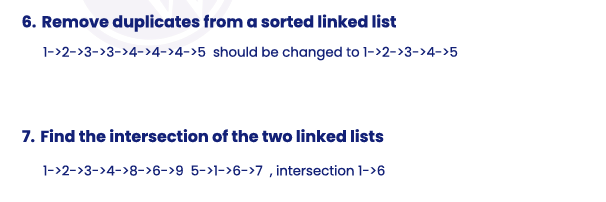

In [6]:
#6
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

def remove_duplicates(head):
    current = head
    while current and current.next:
        if current.val == current.next.val:
            current.next = current.next.next
        else:
            current = current.next
    return head

# Example usage
def print_list(node):
    while node:
        print(node.val, end=" -> ")
        node = node.next
    print("None")

head = ListNode(1, ListNode(2, ListNode(3, ListNode(3, ListNode(4, ListNode(4, ListNode(5)))))))
print("Original list:")
print_list(head)

head = remove_duplicates(head)
print("List after removing duplicates:")
print_list(head)


Original list:
1 -> 2 -> 3 -> 3 -> 4 -> 4 -> 5 -> None
List after removing duplicates:
1 -> 2 -> 3 -> 4 -> 5 -> None


In [7]:
#7
def get_intersection_node(headA, headB):
    if not headA or not headB:
        return None

    pointerA, pointerB = headA, headB

    while pointerA != pointerB:
        pointerA = pointerA.next if pointerA else headB
        pointerB = pointerB.next if pointerB else headA

    return pointerA

# Example usage
# List A: 1 -> 2 -> 3 -> 4 -> 8 -> 9
# List B: 5 -> 1 -> 6 -> 7
# Intersection at: 1 -> 6
listA = ListNode(1, ListNode(2, ListNode(3, ListNode(4, ListNode(8, ListNode(9))))))
listB = ListNode(5, ListNode(1, ListNode(6, ListNode(7))))
listB.next.next = listA.next.next.next.next  # Creating intersection at node 8

intersection = get_intersection_node(listA, listB)
if intersection:
    print(f"Intersection at node with value: {intersection.val}")
else:
    print("No intersection found.")


Intersection at node with value: 8


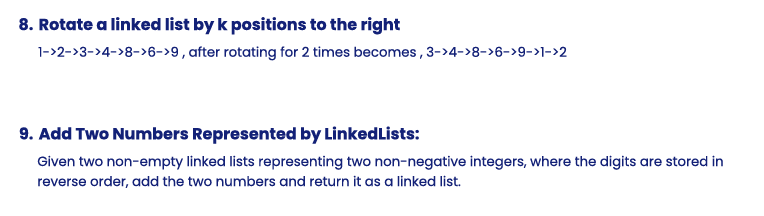

In [8]:
#8
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

def rotate_right(head, k):
    if not head or not head.next or k == 0:
        return head

    # Compute the length of the list
    length = 1
    tail = head
    while tail.next:
        tail = tail.next
        length += 1

    # Make the list circular
    tail.next = head

    # Find the new head after rotation
    k = k % length
    steps_to_new_head = length - k
    new_tail = head
    for _ in range(steps_to_new_head - 1):
        new_tail = new_tail.next
    new_head = new_tail.next

    # Break the circular list
    new_tail.next = None
    return new_head

# Example usage
def print_list(node):
    while node:
        print(node.val, end=" -> ")
        node = node.next
    print("None")

head = ListNode(1, ListNode(2, ListNode(3, ListNode(4, ListNode(8, ListNode(6, ListNode(9)))))))
print("Original list:")
print_list(head)

k = 2
rotated_head = rotate_right(head, k)
print(f"List after rotating {k} positions to the right:")
print_list(rotated_head)


Original list:
1 -> 2 -> 3 -> 4 -> 8 -> 6 -> 9 -> None
List after rotating 2 positions to the right:
6 -> 9 -> 1 -> 2 -> 3 -> 4 -> 8 -> None


In [9]:
#9
def add_two_numbers(l1, l2):
    dummy_head = ListNode(0)
    current = dummy_head
    carry = 0

    while l1 or l2:
        x = l1.val if l1 else 0
        y = l2.val if l2 else 0
        sum_value = carry + x + y
        carry = sum_value // 10
        current.next = ListNode(sum_value % 10)
        current = current.next

        if l1:
            l1 = l1.next
        if l2:
            l2 = l2.next

    if carry > 0:
        current.next = ListNode(carry)

    return dummy_head.next

# Example usage
l1 = ListNode(2, ListNode(4, ListNode(3)))  # Represents number 342
l2 = ListNode(5, ListNode(6, ListNode(4)))  # Represents number 465

result = add_two_numbers(l1, l2)
print("Sum of the numbers represented by linked lists:")
print_list(result)  # Output should be 7 -> 0 -> 8 (which represents 807)


Sum of the numbers represented by linked lists:
7 -> 0 -> 8 -> None


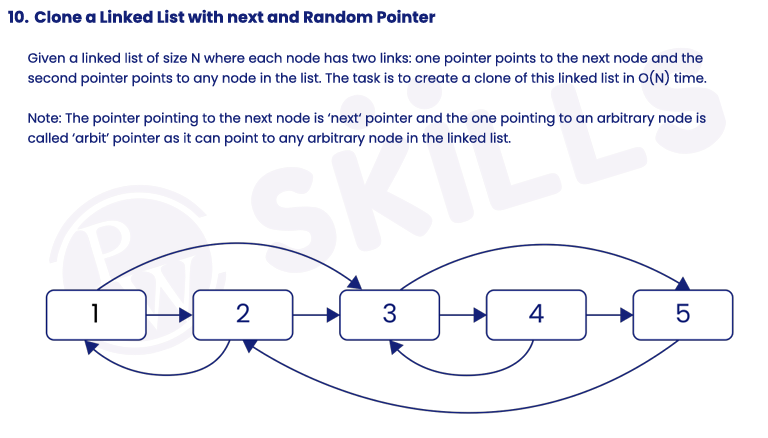

To solve the problem of cloning a linked list with both next and random (arbitrary) pointers in
𝑂
(
𝑁
)
O(N) time, we'll use a three-step process:

Steps:
Clone Nodes and Insert Them into the Original List:

For each node in the original list, create a new node with the same value.
Insert each new node immediately after its corresponding original node.
Assign Random Pointers to the Cloned Nodes:

Traverse the updated list, and for each original node, set the random pointer of the cloned node to point to the clone of the original node's random pointer.
Restore the Original List and Extract the Cloned List:

Separate the cloned nodes from the original list, restoring the original list to its initial state and collecting the cloned nodes into a new list.

In [10]:
#10
class Node:
    def __init__(self, val, next=None, random=None):
        self.val = val
        self.next = next
        self.random = random

def print_list(node):
    while node:
        random_val = node.random.val if node.random else "None"
        print(f"Node({node.val}) -> Random({random_val})")
        node = node.next

def clone_linked_list_with_random_pointer(head):
    if not head:
        return None

    # Step 1: Clone nodes and insert them next to the original nodes
    current = head
    while current:
        new_node = Node(current.val)
        new_node.next = current.next
        current.next = new_node
        current = new_node.next

    # Step 2: Assign random pointers to the cloned nodes
    current = head
    while current:
        current.next.random = current.random.next if current.random else None
        current = current.next.next

    # Step 3: Separate the original and cloned lists
    original = head
    clone = head.next
    clone_head = head.next

    while original and clone:
        original.next = original.next.next
        clone.next = clone.next.next if clone.next else None
        original = original.next
        clone = clone.next

    return clone_head

# Example usage:
# Creating a linked list with random pointers
node1 = Node(1)
node2 = Node(2)
node3 = Node(3)
node4 = Node(4)
node5 = Node(5)

node1.next = node2
node2.next = node3
node3.next = node4
node4.next = node5

node1.random = node3
node2.random = node1
node3.random = node5
node4.random = node3
node5.random = node2

print("Original list:")
print_list(node1)

cloned_head = clone_linked_list_with_random_pointer(node1)

print("\nCloned list:")
print_list(cloned_head)


Original list:
Node(1) -> Random(3)
Node(2) -> Random(1)
Node(3) -> Random(5)
Node(4) -> Random(3)
Node(5) -> Random(2)

Cloned list:
Node(1) -> Random(3)
Node(2) -> Random(1)
Node(3) -> Random(5)
Node(4) -> Random(3)
Node(5) -> Random(2)
